In [103]:
import polars as pl
import glob
from pathlib import Path
import glob
import os
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [68]:
path = "../ingestion/data/backup/earnings_delta_backup.parquet"
df_er = pl.read_parquet(path)

In [69]:
df_er

fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,fiscal_month,fiscal_year,av_quarter,time_from
date,date,str,str,str,str,str,str,i8,i32,str,str
2015-09-30,2015-11-06,"""1.85""","""1.85""","""0""","""0""","""post-market""","""BRK-B""",9,2015,"""2015Q3""","""20151106T0000"""
2019-03-31,2019-05-04,"""2.26""","""2.29""","""-0.03""","""-1.31""","""pre-market""","""BRK-B""",3,2019,"""2019Q1""","""20190504T0000"""
2017-09-30,2017-11-03,"""1.4""","""1.58""","""-0.18""","""-11.3924""","""post-market""","""BRK-B""",9,2017,"""2017Q3""","""20171103T0000"""
2016-12-31,2017-02-25,"""1.78""","""1.83""","""-0.05""","""-2.7322""","""pre-market""","""BRK-B""",12,2016,"""2016Q4""","""20170225T0000"""
2023-06-30,2023-08-05,"""4.62""","""3.87""","""0.75""","""19.3798""","""pre-market""","""BRK-B""",6,2023,"""2023Q2""","""20230805T0000"""
…,…,…,…,…,…,…,…,…,…,…,…
2014-09-30,2014-10-22,"""0.02""","""0.02""","""0""","""0""","""post-market""","""FTNT""",9,2014,"""2014Q3""","""20141022T0000"""
2025-09-30,2025-11-05,"""0.74""","""0.63""","""0.11""","""17.4603""","""post-market""","""FTNT""",9,2025,"""2025Q3""","""20251105T0000"""
2025-03-31,2025-05-07,"""0.58""","""0.53""","""0.05""","""9.434""","""post-market""","""FTNT""",3,2025,"""2025Q1""","""20250507T0000"""


In [87]:
# news compacted path
news_path = "../ingestion/data/backup/compacted_news.parquet"
df_news = pl.read_parquet(news_path)

# remove banner_image column column from df_news
df_news = df_news.drop("banner_image")


In [88]:
path = "../../temp/data/"

# Get a list of all columns except the one you want to drop
all_columns = pl.read_parquet_schema(path).keys()
columns_to_keep = [col for col in all_columns if col != "banner_image"]
columns_to_keep += ["file_path"]

In [89]:
# news temp path 
path ="../../temp/data/"



data_dir = Path(path)

glob_pattern= str(data_dir / "*.parquet")
# 1. Scan all files lazily and include the file path metadata
df_1415 = (
    pl.read_parquet(glob_pattern, include_file_paths="file_path", columns = columns_to_keep )
    
    # 2. Extract just the symbol from the path string using a Polars expression
    # This strips out everything before the filename and drops the ".parquet" extension
    .with_columns(
        pl.col("file_path")
        .str.split(os.sep)       # Split path by system folder separator (/ or \)
        .list.last()             # Get the last item (e.g., "AAPL.parquet")
        .str.replace(".parquet", "") # Strip the extension to leave just "AAPL"
        .alias("symbol")         # Name the new column 'symbol'
    )
    
    # 3. Drop the temporary full path column so your schema stays perfectly clean
    .drop("file_path")
    
    # 4. Trigger the multi-threaded parallel execution engine
    
)

print(df.shape)


(18990, 13)


In [90]:
# col diff between df_news and df_1415
set(df_news.columns) - set(df_1415.columns)

set()

In [91]:
df_nx = pl.concat([df_1415, df_news], how="vertical")
df_nx['time_published'].min(), df_nx['time_published'].max()

(datetime.datetime(2014, 1, 1, 0, 0), datetime.datetime(2025, 12, 31, 23, 45))

In [ ]:
# write compacted total back to backup
# df_nx.write_parquet("../ingestion/data/backup/compacted_news_temp_14_25.parquet")

In [94]:
df_nx['symbol'].unique()
df_er['symbol'].unique()

# checking whats missing in df_nx compared to df_er
symbols_er = set(df_er['symbol'].unique())
symbols_nx = set(df_nx['symbol'].unique())
missing_in_nx = symbols_er - symbols_nx
print(f"Symbols in df_er but not in df_nx: {missing_in_nx}")

Symbols in df_er but not in df_nx: set()


In [95]:

df_nx.schema


Schema([('title', String),
        ('url', String),
        ('time_published', Datetime(time_unit='us', time_zone=None)),
        ('authors', List(String)),
        ('summary', String),
        ('source', String),
        ('category_within_source', String),
        ('source_domain', String),
        ('topics', List(Struct({'topic': String, 'relevance_score': String}))),
        ('overall_sentiment_score', Float64),
        ('overall_sentiment_label', String),
        ('ticker_sentiment',
         List(Struct({'ticker': String, 'relevance_score': String, 'ticker_sentiment_score': String, 'ticker_sentiment_label': String}))),
        ('symbol', String)])

In [100]:
df_nx.schema, df_nx.shape

(Schema([('title', String),
         ('url', String),
         ('time_published', Datetime(time_unit='us', time_zone=None)),
         ('authors', List(String)),
         ('summary', String),
         ('source', String),
         ('category_within_source', String),
         ('source_domain', String),
         ('topics',
          List(Struct({'topic': String, 'relevance_score': String}))),
         ('overall_sentiment_score', Float64),
         ('overall_sentiment_label', String),
         ('ticker_sentiment',
          List(Struct({'ticker': String, 'relevance_score': String, 'ticker_sentiment_score': String, 'ticker_sentiment_label': String}))),
         ('symbol', String)]),
 (789613, 13))

In [99]:
df_nx.glimpse()

Rows: 789613
Columns: 13
$ title                               <str> 'Agilent to commence its operations under new name Keysight Technologies from August 1', 'Agilent Technologies Introduces Enhanced Chromatography Data System Software for Lab Productivity', 'Agilent Technologies Adds Averager Capability to PCIe Digitizers', 'Agilent becomes Keysight Technologies', "Agilent's Folsom office to keep company name after spinoff", 'UD grad to become CEO Agilent Technologies', 'Biz Break: Agilent completes Keysight spinoff as HP and eBay hop on same path', 'Agilent Technologies officially spins off e-measurement business Keysight', "Why Carly Fiorina's Business Record Upsets So Many People", 'Agilent Technologies and Waters Corporation Formalize Instrument Control Exchange'
$ url                                 <str> 'https://www.electronicsforyou.biz/industry-buzz/agilent-to-commence-its-operations-under-new-name-keysight-technologies-from-august-1/', 'https://www.pandct.com/news/agilent-te

In [104]:
analyzer = SentimentIntensityAnalyzer()

In [105]:
df_nx = df_nx.with_columns([
    # Character & Word Counts
    pl.col("title").str.len_chars().alias("title_char_len"),
    pl.col("summary").str.len_chars().alias("summary_char_len"),
    pl.col("title").str.split(" ").list.len().alias("title_word_count"),
    pl.col("summary").str.split(" ").list.len().alias("summary_word_count"),
    
    # Text cleaning: Lowercase and strip special characters/punctuation
    pl.col("summary")
    .str.to_lowercase()
    .str.replace_all(r"[^\w\s]", "")
    .alias("cleaned_summary")
])

In [106]:
df_nx = df_nx.with_columns(
    pl.col("cleaned_summary")
    .map_elements(
        lambda text: analyzer.polarity_scores(text if text is not None else ""),
        return_dtype=pl.Struct([
            pl.Field("neg", pl.Float64),
            pl.Field("neu", pl.Float64),
            pl.Field("pos", pl.Float64),
            pl.Field("compound", pl.Float64)
        ])
    )
    .alias("vader_scores")
).unnest("vader_scores") 

In [108]:
df_nx

title,url,time_published,authors,summary,source,category_within_source,source_domain,topics,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,symbol,title_char_len,summary_char_len,title_word_count,summary_word_count,cleaned_summary,neg,neu,pos,compound
str,str,datetime[μs],list[str],str,str,str,str,list[struct[2]],f64,str,list[struct[4]],str,u32,u32,u32,u32,str,f64,f64,f64,f64
"""Agilent to commence its operat…","""https://www.electronicsforyou.…",2014-01-29 09:56:08,"[""admin""]","""Agilent Technologies will begi…","""Electronics For You BUSINESS""","""General""","""Electronics For You BUSINESS""","[{""mergers_and_acquisitions"",""0.809498""}, {""technology"",""0.744181""}, {""life_sciences"",""0.637082""}]",0.297357,"""Somewhat-Bullish""","[{""A"",""1.000000"",""0.259351"",""Somewhat-Bullish""}, {""KEYS"",""1.000000"",""0.265008"",""Somewhat-Bullish""}]","""A""",85,381,13,56,"""agilent technologies will begi…",0.0,1.0,0.0,0.0
"""Agilent Technologies Introduce…","""https://www.pandct.com/news/ag…",2014-05-09 09:56:07,[],"""Agilent Technologies Inc. (NYS…","""Process and Control Today""","""General""","""Process and Control Today""","[{""technology"",""0.829393""}, {""life_sciences"",""0.749510""}, {""manufacturing"",""0.610333""}]",0.47104,"""Bullish""","[{""A"",""1.000000"",""0.468223"",""Bullish""}]","""A""",97,527,11,68,"""agilent technologies inc nyse …",0.0,0.838,0.162,0.8807
"""Agilent Technologies Adds Aver…","""https://www.designworldonline.…",2014-07-02 09:56:07,"[""WDD Staff""]","""Agilent Technologies has intro…","""Design World""","""General""","""Design World""","[{""technology"",""0.931242""}]",0.39441,"""Bullish""","[{""A"",""1.000000"",""0.388517"",""Bullish""}]","""A""",64,411,8,57,"""agilent technologies has intro…",0.0,0.956,0.044,0.3818
"""Agilent becomes Keysight Techn…","""https://www.embedded.com/agile…",2014-08-02 09:56:07,[],"""Agilent Technologies' electron…","""www.embedded.com""","""General""","""www.embedded.com""","[{""mergers_and_acquisitions"",""0.925477""}, {""technology"",""0.815355""}, {""ipo"",""0.708177""}]",0.349113,"""Somewhat-Bullish""","[{""A"",""1.000000"",""0.345220"",""Somewhat-Bullish""}, {""KEYS"",""0.926671"",""0.336600"",""Somewhat-Bullish""}]","""A""",37,453,4,63,"""agilent technologies electroni…",0.0,0.976,0.024,0.128
"""Agilent's Folsom office to kee…","""https://www.bizjournals.com/sa…",2014-09-03 09:56:07,"[""Mark Anderson""]","""Agilent Technologies Inc. will…","""The Business Journals""","""General""","""The Business Journals""","[{""mergers_and_acquisitions"",""0.935358""}, {""technology"",""0.805007""}]",0.131274,"""Neutral""","[{""A"",""1.000000"",""0.136645"",""Neutral""}, {""KEYS"",""0.807961"",""0.119888"",""Neutral""}]","""A""",58,221,9,31,"""agilent technologies inc will …",0.0,1.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Boston Scientific (BSX) Stock …","""https://ts2.tech/en/boston-sci…",2025-12-25 03:08:20,"[""Khadija Saeed""]","""Boston Scientific (NYSE: BSX) …","""ts2.tech""","""General""","""ts2.tech""","[{""financial_markets"",""0.919847""}, {""earnings"",""0.831648""}, {""life_sciences"",""0.702408""}]",0.184648,"""Somewhat-Bullish""","[{""BSX"",""1.000000"",""0.300000"",""Somewhat-Bullish""}, {""ZTS"",""0.561013"",""0.049371"",""Neutral""}, … {""ABT"",""0.574339"",""0.240802"",""Somewhat-Bullish""}]","""ZTS""",134,468,22,66,"""boston scientific nyse bsx exp…",0.069,0.885,0.046,-0.1496
"""Yousif Capital Management LLC …","""https://www.marketbeat.com/ins…",2025-12-27 14:09:06,"[""MarketBeat""]","""Yousif Capital Management LLC …","""MarketBeat""","""General""","""MarketBeat""","[{""earnings"",""0.945007""}, {""financial_markets"",""0.802718""}, {""life_sciences"",""0.700296""}]",0.299451,"""Somewhat-Bullish""","[{""ELAN"",""1.000000"",""0.476012"",""Bullish""}, {""ZTS"",""0.648012"",""0.128038"",""Neutral""}]","""ZTS""",94,370,13,53,"""yousif capital management llc …",0.0,0.744,0.256,0.9349
"""Zoetis (ZTS) Positioned Within…"

In [109]:
# 3. Structural EDA: Exploding Nested Complex Fields
exploded_tickers = (
    df_nx.select(["symbol", "ticker_sentiment"])
    .explode("ticker_sentiment")
    .unnest("ticker_sentiment")
    .filter(pl.col("ticker").is_not_null())
)

exploded_topics = (
    df_nx.select(["symbol", "topics"])
    .explode("topics")
    .unnest("topics")
    .filter(pl.col("topic").is_not_null())
)

In [110]:
df_nx = df_nx.with_columns([
    pl.col("time_published").dt.year().alias("pub_year"),
    pl.col("time_published").dt.month().alias("pub_month"),
    pl.col("time_published").dt.weekday().alias("pub_day_of_week"),
])

In [111]:
print("=== Shape of Processed Frame ===")
print(df_nx.shape)

print("\n=== VADER Compound Score Distribution ===")
print(df_nx.select(["compound"]).describe())

print("\n=== Top 10 Macro Topics Extracted ===")
print(
    exploded_topics.group_by("topic")
    .len(name="topic_count")
    .sort("topic_count", descending=True)
    .head(10)
)

print("\n=== Top 10 Tickers Mentioned ===")
print(
    exploded_tickers.group_by("ticker")
    .len(name="mention_count")
    .sort("mention_count", descending=True)
    .head(10)
)

=== Shape of Processed Frame ===
(789613, 25)

=== VADER Compound Score Distribution ===
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ compound │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 789377.0 │
│ null_count ┆ 236.0    │
│ mean       ┆ 0.53058  │
│ std        ┆ 0.479894 │
│ min        ┆ -0.9914  │
│ 25%        ┆ 0.34     │
│ 50%        ┆ 0.7351   │
│ 75%        ┆ 0.8779   │
│ max        ┆ 0.9951   │
└────────────┴──────────┘

=== Top 10 Macro Topics Extracted ===
shape: (10, 2)
┌──────────────────────────┬─────────────┐
│ topic                    ┆ topic_count │
│ ---                      ┆ ---         │
│ str                      ┆ u32         │
╞══════════════════════════╪═════════════╡
│ financial_markets        ┆ 341106      │
│ finance                  ┆ 321625      │
│ earnings                 ┆ 288162      │
│ technology               ┆ 253024      │
│ economy_macro            ┆ 154734      │
│ energy_transportation

/var/folders/vb/3jgmd9r10vj286ss2tn5s_9m0000gn/T/ipykernel_34247/1920762556.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/vb/3jgmd9r10vj286ss2tn5s_9m0000gn/T/ipykernel_34247/1920762556.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


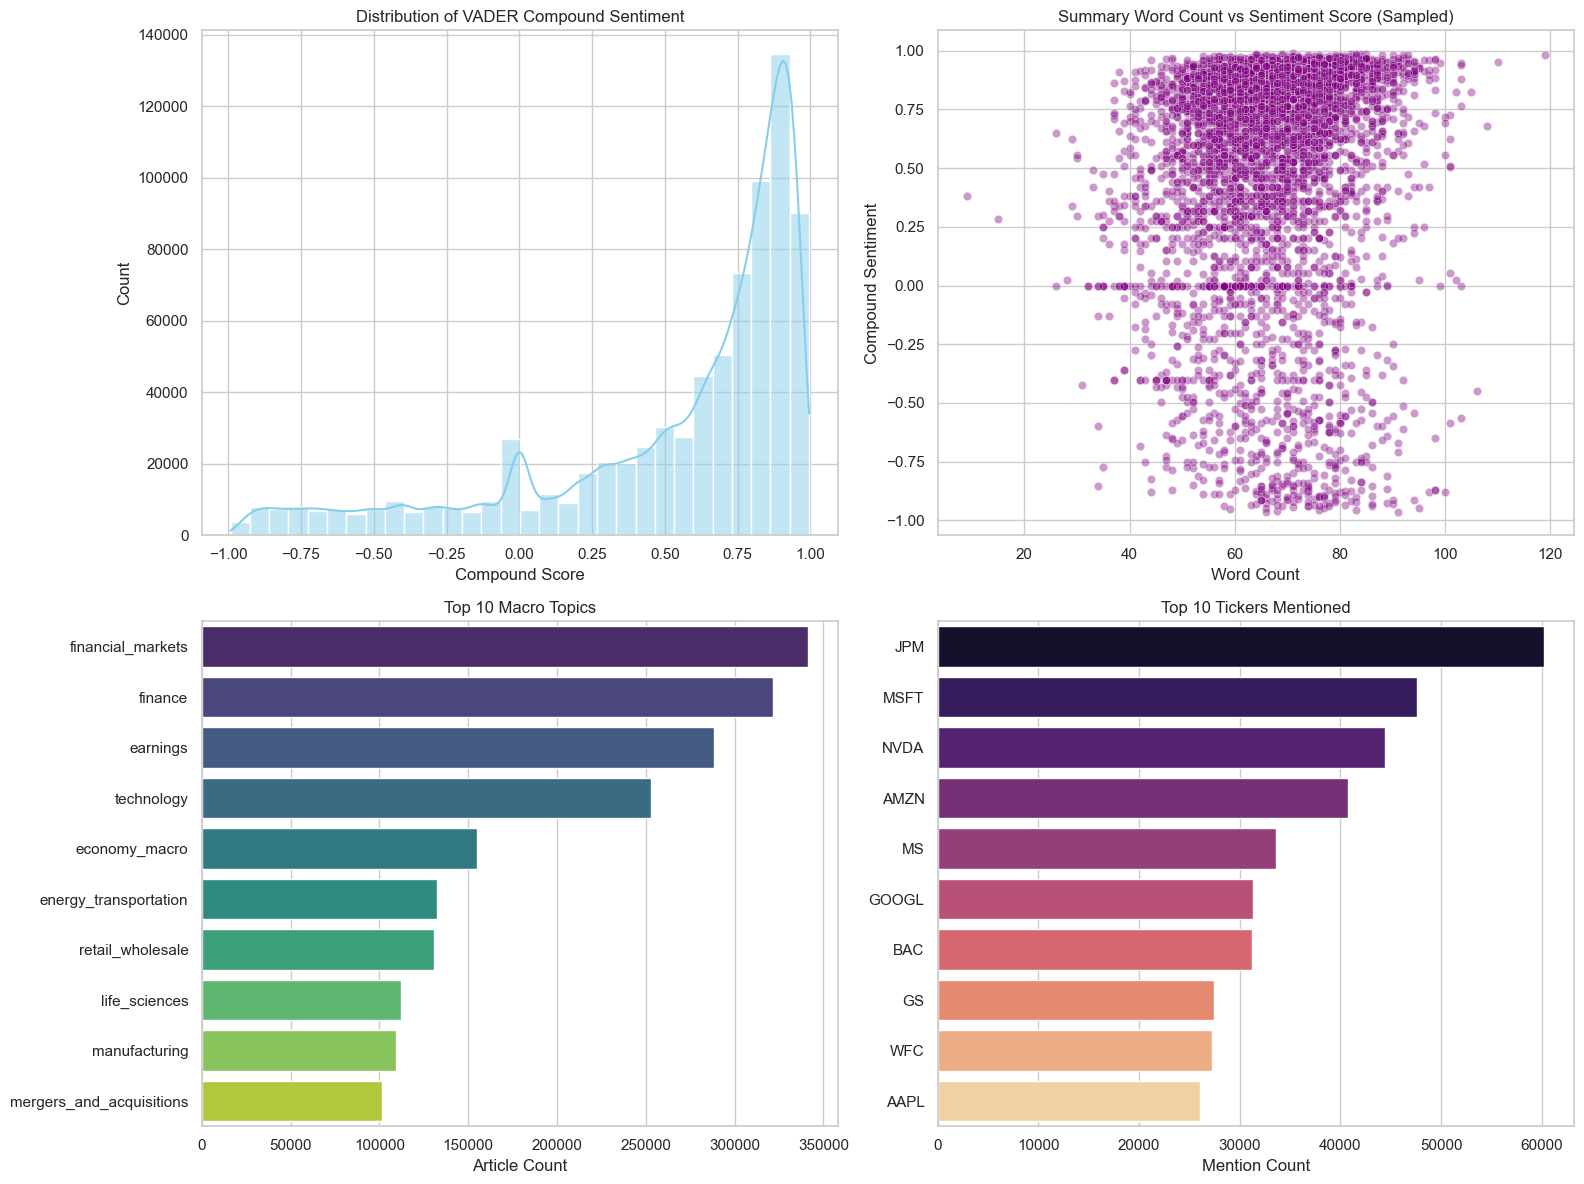

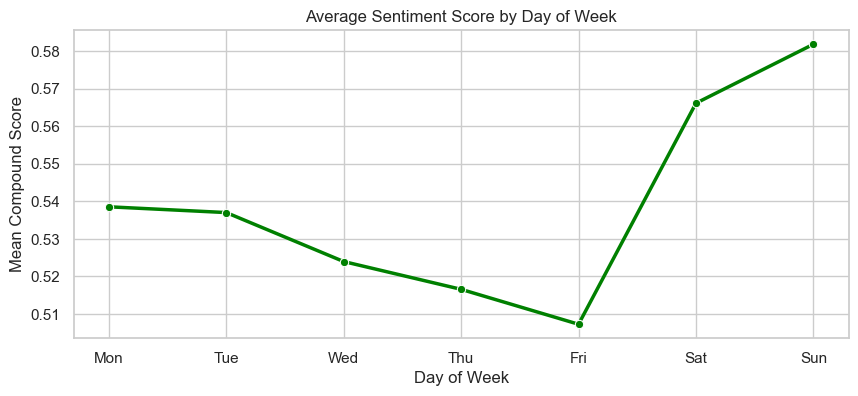

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of VADER Compound Sentiment Scores
sns.histplot(
    data=df_nx["compound"].to_numpy(), 
    bins=30, 
    kde=True, 
    ax=axes[0, 0], 
    color="skyblue"
)
axes[0, 0].set_title("Distribution of VADER Compound Sentiment")
axes[0, 0].set_xlabel("Compound Score")
axes[0, 0].set_ylabel("Count")

# 2. Text Length vs Sentiment (Sampled for speed across 790k rows)
df_sample = df_nx.sample(n=5000, seed=42)
sns.scatterplot(
    x=df_sample["summary_word_count"].to_numpy(),
    y=df_sample["compound"].to_numpy(),
    alpha=0.4,
    ax=axes[0, 1],
    color="purple"
)
axes[0, 1].set_title("Summary Word Count vs Sentiment Score (Sampled)")
axes[0, 1].set_xlabel("Word Count")
axes[0, 1].set_ylabel("Compound Sentiment")

# 3. Top 10 Topics Bar Plot
top_topics = (
    exploded_topics.group_by("topic")
    .len(name="topic_count")
    .sort("topic_count", descending=True)
    .head(10)
)
sns.barplot(
    x=top_topics["topic_count"].to_numpy(),
    y=top_topics["topic"].to_numpy(),
    ax=axes[1, 0],
    palette="viridis"
)
axes[1, 0].set_title("Top 10 Macro Topics")
axes[1, 0].set_xlabel("Article Count")

# 4. Top 10 Most Mentioned Tickers Bar Plot
top_tickers = (
    exploded_tickers.group_by("ticker")
    .len(name="mention_count")
    .sort("mention_count", descending=True)
    .head(10)
)
sns.barplot(
    x=top_tickers["mention_count"].to_numpy(),
    y=top_tickers["ticker"].to_numpy(),
    ax=axes[1, 1],
    palette="magma"
)
axes[1, 1].set_title("Top 10 Tickers Mentioned")
axes[1, 1].set_xlabel("Mention Count")

plt.tight_layout()
plt.show()


# 5. Bonus: Sentiment Trend Over Days of the Week
plt.figure(figsize=(10, 4))
weekly_trend = (
    df_nx.group_by("pub_day_of_week")
    .agg(pl.col("compound").mean().alias("avg_sentiment"))
    .sort("pub_day_of_week")
)
# Map numbers to day names for clarity
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.lineplot(
    x=days,
    y=weekly_trend["avg_sentiment"].to_numpy(),
    marker="o",
    linewidth=2.5,
    color="green"
)
plt.title("Average Sentiment Score by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Compound Score")
plt.show()

In [3]:
0.000164 * 60 * 60

0.5904

In [4]:
 30 / 0.5904 

50.8130081300813